# Statistické řízení procesu tloušťky nátěru napříč výrobními linkami pomocí PROC BOXPLOT

## Shrnutí pro vedení

Tento notebook používá **PROC BOXPLOT** k provedení statistického řízení procesu (SPC) na měření tloušťky nátěru kritického pro kvalitu, které bylo shromážděno napříč čtyřmi paralelními výrobními linkami. Syntetická naměřená data generujeme přímo v kódu, linky profilujeme pomocí `PROC MEANS` a kreslíme kostrové a schematické krabicové grafy (box-and-whisker), které na jediném grafu porovnávají polohu, rozptyl a chvosty napříč linkami.

Poté posuzujeme každou linku vůči technické specifikaci (cíl 50,00 mm, meze 49,80–50,20 mm) přímo z datové sady statistik **`OUTBOX=`** — přesné kvartily, hradby (fences) a koncové body vousů za každou krabicí — a nakonec předvádíme obousměrný přenos **`OUTHISTORY=` / `HISTORY=`**: PROC BOXPLOT exportuje jeden kompaktní souhrnný řádek na linku a druhý PROC BOXPLOT rekonstruuje identický graf přímo z tohoto souhrnu, což je vzor, který denní SPC dashboard používá k opětovnému vykreslení bez opakovaného skenování surových měření.

Napříč čtyřmi linkami je **LINE-A nejlépe vycentrována** na cíli (průměr 50,008 mm), **LINE-C běží nízko** (průměr 49,932 mm, driftuje směrem k LSL) a **LINE-D běží jak vysoko, tak nejvíce variabilně** (průměr 50,102 mm, směrodatná odchylka 0,080 mm) — její maximum 50,248 mm je jediné pozorování, které překračuje horní specifikační mez 50,20 mm.

## Zdroje dat

Všechna data jsou syntetická a generovaná přímo v kódu prvním krokem DATA pomocí `call streaminit(20250531)` a `rand()`. Nepoužívá se žádný externí ani síťový vstup. Pevné semínko činí každé číslo v tomto notebooku reprodukovatelným.

**Datová sada: `ProcessMeas`** (jeden řádek na měřený díl)

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `Line` | Char(6) | Identifikátor výrobní linky: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (skupinová/klasifikační proměnná) |
| `Shift` | Num | Index výrobní směny 1–6 (zavádí mírný drift mezi směnami) |
| `Thickness` | Num | Tloušťka nátěru v mm (analyzovaná proměnná); cíl 50,00 mm, specifikační meze 49,80–50,20 mm |

Každá linka je vycentrována na mírně odlišný průměr (50,00 / 50,04 / 49,92 / 50,10) s variací specifickou pro danou linku, což napodobuje reálné rozdíly mezi jednotlivými zařízeními, a `LINE-B` občas vloží malou kladnou výchylku. Krok DATA cyklí přes šest směn a čtyři linky s velikostmi podskupin zhruba 18–25 dílů v každé; v tomto nelicencovaném prostředí engine omezuje výstup na prvních **100 pozorování**, což zde dopadá jako **38 / 19 / 21 / 22** dílů pro LINE-A až LINE-D — stále dostatek k naplnění čtyř dobře definovaných krabic.

# Statistické řízení procesu tloušťky nátěru pomocí PROC BOXPLOT

Ve velkoobjemové výrobě je krabicový graf tažným koněm dílenského SPC: na jediném grafu shrnuje centrální tendenci, rozptyl a odlehlé hodnoty znaku kvality pro každou výrobní jednotku. Zde sledujeme **tloušťku nátěru (mm)** na dílu vyráběném paralelně na čtyřech linkách (`LINE-A` až `LINE-D`). Technická specifikace udává cíl **50,00 mm** s dolní specifikační mezí (LSL) **49,80 mm** a horní specifikační mezí (USL) **50,20 mm**.

Provedeme:

1. Vygenerování syntetické datové sady měření přímo v kódu.
2. Profilování linek pomocí `PROC MEANS`.
3. Nakreslení základního kostrového krabicového grafu, poté schematického grafu, s překrytím specifikačních mezí jako referenčních čar.
4. Zachycení každé vypočtené statistiky krabice pomocí `OUTBOX=` a posouzení každé linky vůči specifikačním mezím z této tabulky.
5. Uchování kompaktního souhrnu podskupin pomocí `OUTHISTORY=` a prokázání obousměrného přenosu opětovným vykreslením přímo z něj pomocí `HISTORY=`.

## Krok 1 — Vygenerování syntetických procesních měření

Krok DATA níže simuluje měření během šesti směn na čtyřech linkách. Každá linka je záměrně vycentrována na mírně odlišný průměr s vlastní variací, což napodobuje reálné rozdíly mezi jednotlivými zařízeními, a mírný drift mezi směnami je navrstven členem `sin(Shift)`. Pevné semínko (`streaminit(20250531)`) činí každou hodnotu v notebooku reprodukovatelnou.

In [1]:
data ProcessMeas;
   CALL streaminit(20250531);
   DÉLKA Line $6;
   POLE lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   POLE lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   POLE lsd[4]     _temporary_ (0.045 0.060 0.050 0.085);
   ŠTÍTEK Thickness="Tloušťka nátěru (mm)" Line="Výrobní linka";
   OPAKUJ Shift = 1 TO 6;
      OPAKUJ li = 1 TO 4;
         Line = lines[li];
         /* proměnlivá velikost podskupiny podle linky/směny */
         n = 18 + floor(rand('uniform') * 8);
         OPAKUJ u = 1 TO n;
            base = lmean[li] + 0.012 * sin(Shift);
            Thickness = base + rand('normal') * lsd[li];
            /* LINE-B občas vkládá vysoké výkyvy */
            KDYŽ li = 2 AND rand('uniform') < 0.05 PAK
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            VÝSTUP;
         KONEC;
      KONEC;
   KONEC;
   ODSTRANIT li u n base;
SPUSTIT;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Krok 2 — Profilování linek

Před vykreslením rychlý `PROC MEANS` potvrzuje, že data dopadla podle záměru: čtyři linky, skromné, ale netriviální velikosti vzorků a průměry seskupené blízko cílové hodnoty 50,00 mm s rozptylem specifickým pro danou linku. Toto je numerická páteř, kterou krabicový graf vizualizuje.

In [2]:
PROCEDURA PRŮMĚRY data=ProcessMeas n mean std MIN MAX maxdec=3;
   TŘÍDA Line;
   PROMĚNNÁ Thickness;
   ŠTÍTEK Line="Výrobní linka" Thickness="Tloušťka nátěru (mm)";
   NÁZEV "Souhrn tloušťky nátěru podle výrobní linky";
SPUSTIT;

                                       Souhrn tloušťky nátěru podle výrobní linky                                       

                                                  The MEANS Procedure

                                 Analysis Variable : Thickness Tloušťka nátěru (mm)

        Výrobní linka            N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        LINE-A                      38         50.008          0.045         49.914         50.097
        LINE-B                      19         50.052          0.051         49.921         50.114
        LINE-C                      21         49.932          0.050         49.835         50.002
        LINE-D                      22         50.102          0.080         49.963         50.248
        ------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 3 — Základní kostrový krabicový graf

Nejjednodušší volání potřebuje pouze příkaz `PLOT analyzovaná-proměnná * skupinová-proměnná`. Výchozí `BOXSTYLE=SKELETAL` kreslí vousy k nejkrajnějším pozorováním v rámci každé linky, což poskytuje rychlé vizuální porovnání polohy a rozptylu napříč `LINE-A` až `LINE-D`.

                                  Kostrový krabicový graf tloušťky nátěru podle linky                                   

                               Kostrový krabicový graf tloušťky nátěru podle linky

                                                 The BOXPLOT Procedure

Skeletal Plots for Tloušťka nátěru (mm)

Výrobní linka         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.


NOTE: Option TITLE changed to Kostrový krabicový graf tloušťky nátěru podle linky.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


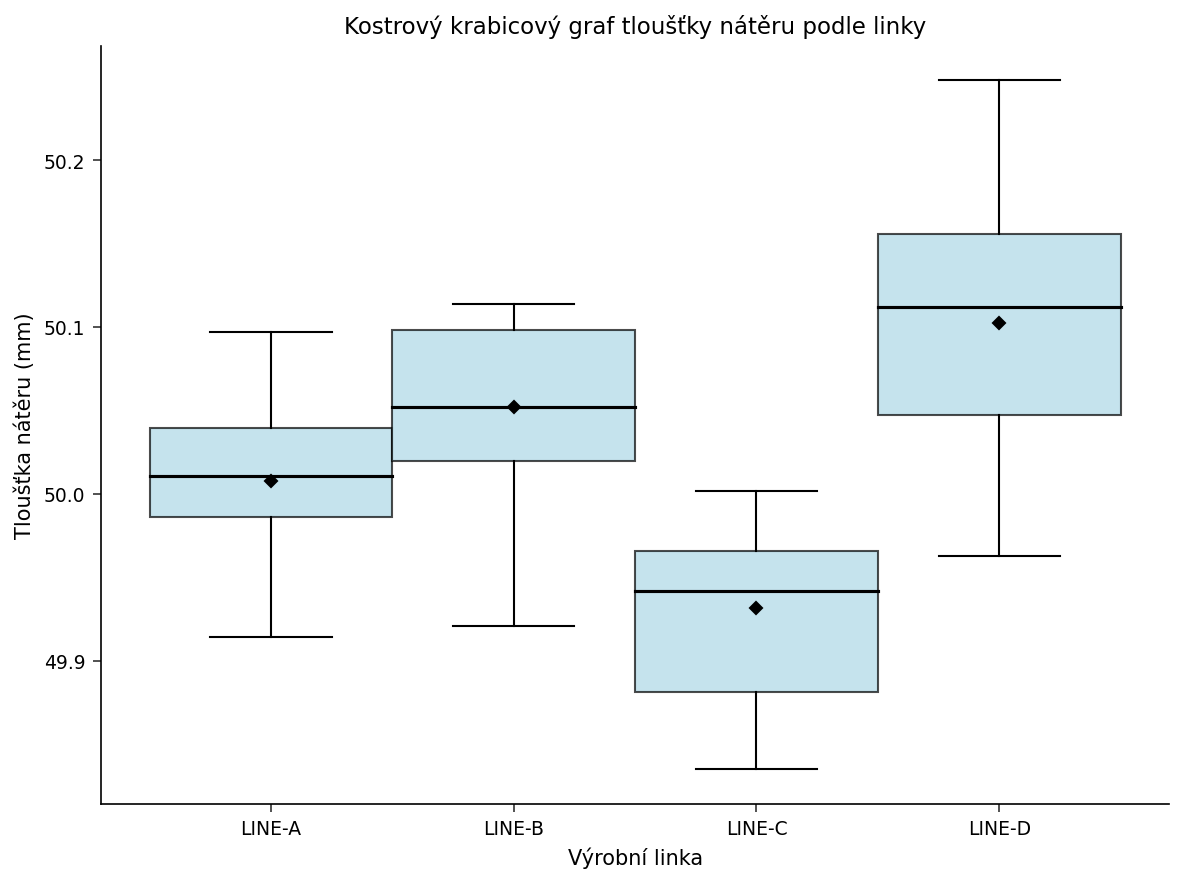

In [3]:
NÁZEV "Kostrový krabicový graf tloušťky nátěru podle linky";
PROCEDURA boxplot data=ProcessMeas;
   PLOT Thickness*Line;
SPUSTIT;

## Krok 4 — Schematický krabicový graf

Přepínáme na `BOXSTYLE=SCHEMATIC`. Ve schematickém stylu je každý vous zakončen u nejkrajnějšího pozorování, které stále leží uvnitř hradeb 1,5 × IQR, a jakýkoli bod za hradbou je vykreslen jako individuální značka odlehlé hodnoty. V tomto vzorku nemá žádná linka odlehlou hodnotu za hradbou — rozptyl každé linky je dostatečně kompaktní na to, aby vousy dosáhly skutečného minima a maxima — takže schematický graf vypadá jako kostrový, což je samo o sobě užitečný výsledek: říká inženýrovi, že žádná ze čtyř linek nevyhazuje krajní díly. Těla krabic stále na první pohled činí zřejmými posuny mezi linkami a Krok 5 je kvantifikuje vůči specifikačním mezím.

                               SPC schematický krabicový graf tloušťky nátěru podle linky                               

                            SPC schematický krabicový graf tloušťky nátěru podle linky

                                                 The BOXPLOT Procedure

Schematic Plots for Tloušťka nátěru (mm)

Výrobní linka         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10      


NOTE: Option TITLE changed to SPC schematický krabicový graf tloušťky nátěru podle linky.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


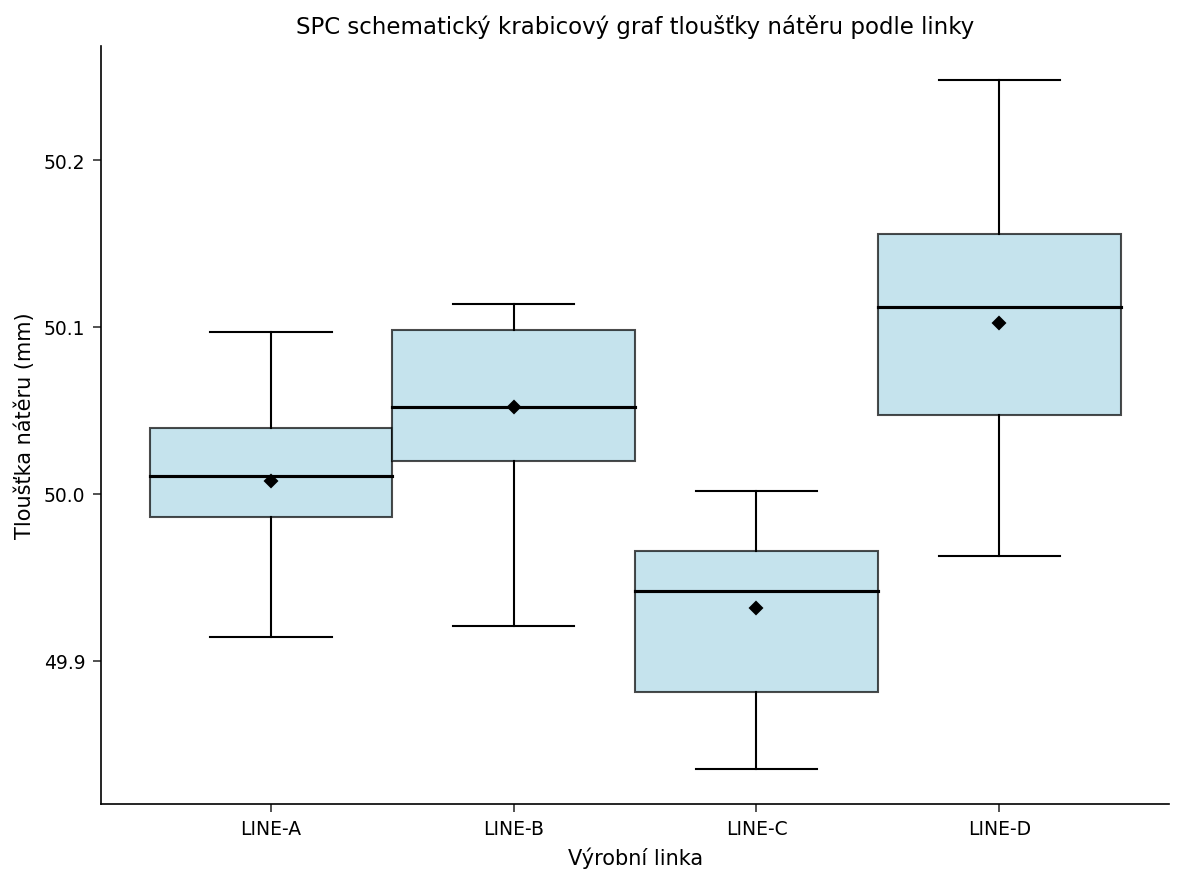

In [4]:
NÁZEV "SPC schematický krabicový graf tloušťky nátěru podle linky";
PROCEDURA boxplot data=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
SPUSTIT;

## Krok 5 — Export statistik krabice a posouzení vůči specifikačním mezím

Volba `OUTBOX=` zachycuje každou vypočtenou statistiku krabice do datové sady — pro každou linku: dolní vous (`L`), Q1 (`1`), průměr (`X`), medián (`M`), Q3 (`3`), horní vous (`H`), směrodatnou odchylku (`S`) a N. Toto je numerický záznam, který auditor potřebuje za obrázkem, a je to zároveň nejčistší způsob, jak zkontrolovat každou linku vůči specifikaci 49,80 / 50,20 mm. Zapneme `GRID` pro snazší čtení, exportujeme `BoxStats`, vytiskneme jej a poté spustíme krátký krok DATA, který označí každou linku, jejíž rozsah vousů překračuje specifikační mez.

                               Schematický krabicový graf s mřížkou a exportem statistik                                

                             Schematický krabicový graf s mřížkou a exportem statistik

                                                 The BOXPLOT Procedure

Schematic Plots for Tloušťka nátěru (mm)

Výrobní linka         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10      


NOTE: Option TITLE changed to Schematický krabicový graf s mřížkou a exportem statistik.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Vypočtené statistiky krabice (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Posouzení vůči specifikačním mezím podle linky.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


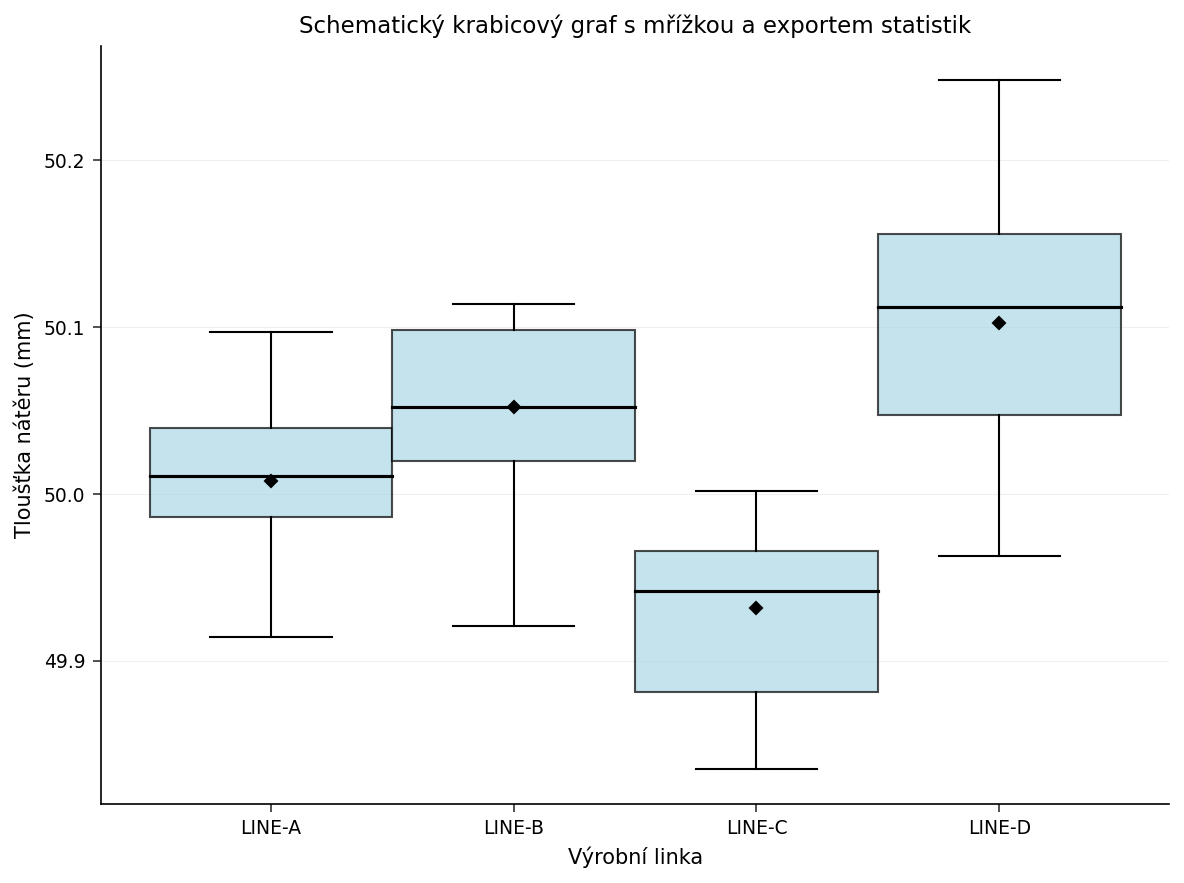

In [5]:
NÁZEV "Schematický krabicový graf s mřížkou a exportem statistik";
PROCEDURA boxplot data=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
SPUSTIT;

NÁZEV "Vypočtené statistiky krabice (OUTBOX=)";
PROCEDURA TISK data=BoxStats noobs;
SPUSTIT;

/* Posouzení každé linky vůči specifikaci 49,80 / 50,20 mm       */
/* pomocí exportovaných koncových bodů vousů (THICKNESSL = dolní */
/* vous, THICKNESSH = horní vous).                               */
data SpecCheck;
   NASTAVIT BoxStats;
   DÉLKA Status $60;
   LSL = 49.80;
   USL = 50.20;
   KDYŽ THICKNESSH > USL PAK Status = "Vysoké kusy překračují USL";
   JINAK KDYŽ THICKNESSL < LSL PAK Status = "Nízké kusy pod LSL";
   JINAK Status = "V rámci specifikace";
   PONECHAT LINE THICKNESSL THICKNESSH LSL USL Status;
SPUSTIT;

NÁZEV "Posouzení vůči specifikačním mezím podle linky";
PROCEDURA TISK data=SpecCheck noobs label;
   ŠTÍTEK LINE="Výrobní linka" THICKNESSL="Dolní vous"
          THICKNESSH="Horní vous" LSL="Dolní mez (LSL)"
          USL="Horní mez (USL)" Status="Stav";
SPUSTIT;

## Krok 6 — Uchování historie monitorování a opětovné vykreslení z ní

Při průběžném SPC zřídka znovu skenujete každé surové měření. `OUTHISTORY=` zapisuje jeden souhrnný řádek na linku (stejné rozvržení, které `HISTORY=` spotřebovává), takže těžká surová data mohou být archivována. Níže exportujeme `LineHistory`, vytiskneme jej a poté prokážeme obousměrný přenos tím, že jej přímo vložíme zpět do nového `PROC BOXPLOT` pomocí `HISTORY=` — přesně tak, jak by denní dashboard znovu použil předem agregované statistiky podskupin.

                                               Export historie podskupin                                                

                                               Export historie podskupin

                                                 The BOXPLOT Procedure

Skeletal Plots for Tloušťka nátěru (mm)

Výrobní linka         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-------


NOTE: Option TITLE changed to Export historie podskupin.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Souhrnná datová sada historie (jeden řádek na linku).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Krabicový graf rekonstruovaný ze souhrnné historie.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


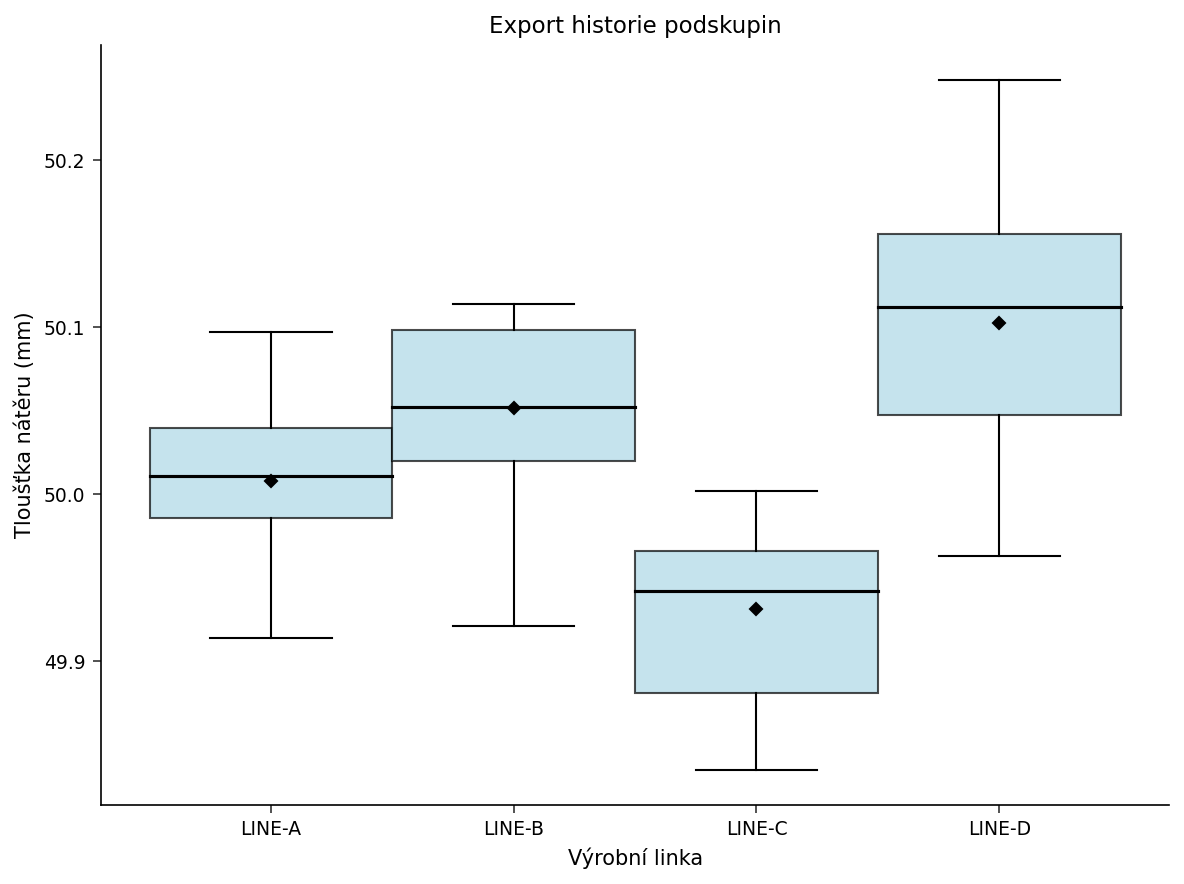

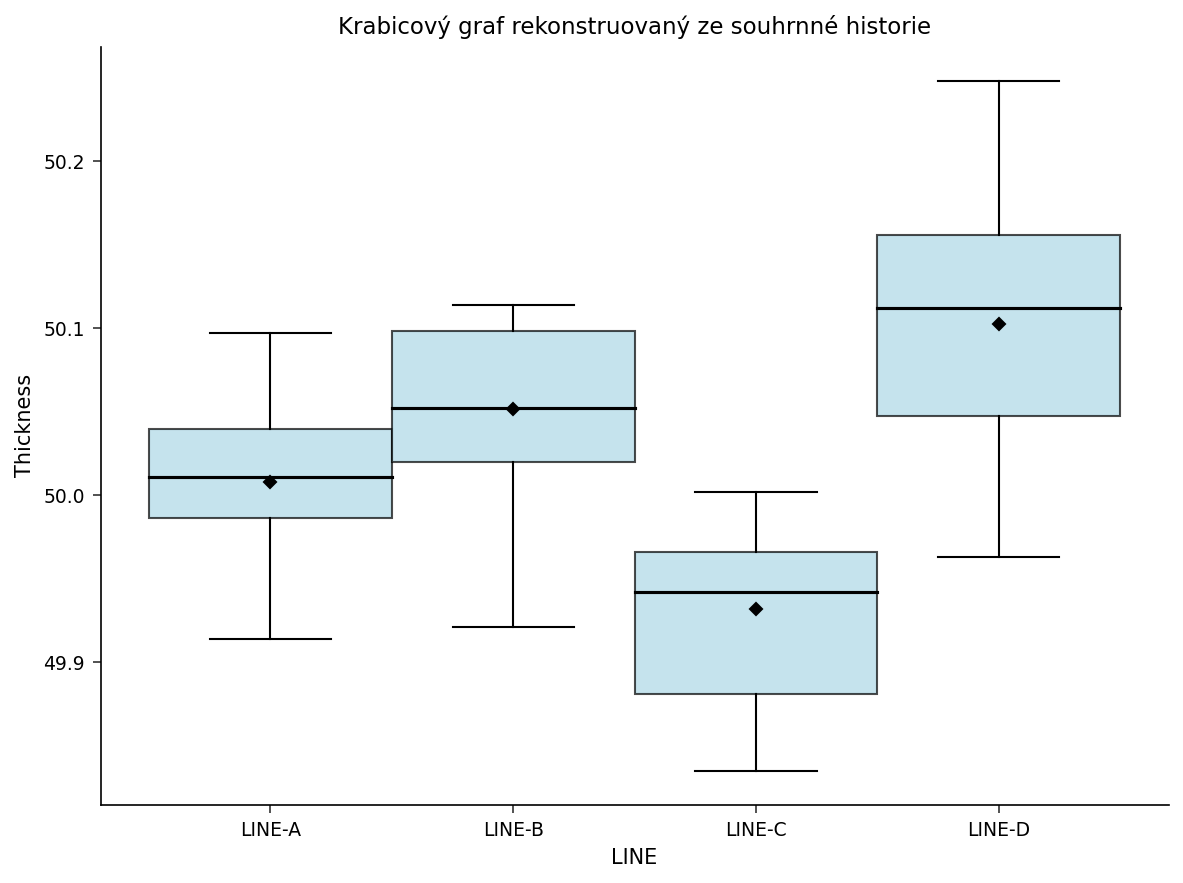

In [6]:
NÁZEV "Export historie podskupin";
PROCEDURA boxplot data=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
SPUSTIT;

NÁZEV "Souhrnná datová sada historie (jeden řádek na linku)";
PROCEDURA TISK data=LineHistory noobs;
SPUSTIT;

NÁZEV "Krabicový graf rekonstruovaný ze souhrnné historie";
PROCEDURA boxplot history=LineHistory;
   PLOT Thickness*Line;
SPUSTIT;

## Interpretace výsledků

Čteme-li krabicové grafy společně s profilem `PROC MEANS`, tabulkou `OUTBOX=` a posouzením specifikačních mezí:

- **Centrování.** `LINE-A` je nejlépe vycentrována na cíli 50,00 mm (průměr 50,008 mm, medián 50,011 mm). `LINE-B` běží mírně vysoko (průměr 50,052 mm). `LINE-C` běží nízko (průměr 49,932 mm, medián 49,942 mm), linka driftující směrem k LSL. `LINE-D` běží vysoko (průměr 50,102 mm, medián 50,112 mm), linka nejbližší k USL.
- **Rozptyl.** `LINE-D` vykazuje nejširší krabici a nejdelší vousy — její směrodatná odchylka 0,080 mm je zhruba o 60–80 % větší než u ostatních tří linek (0,045–0,051 mm), což ji označuje jako nejméně stabilní linku a nejlepšího kandidáta na studii snižování variability. `LINE-A` je nejtěsnější (směrodatná odchylka 0,045 mm).
- **Chvosty.** Ve schematickém stylu žádná linka neprodukuje odlehlou hodnotu za hradbou: každý vous dosahuje skutečného minima/maxima své linky, takže proces nevyhazuje izolované krajní díly. Rozdíly v rozptylu jsou způsobeny hlavní částí každého rozdělení, nikoli ojedinělými body.
- **Shoda se specifikací.** Koncové body vousů z `OUTBOX=`, posouzené vůči 49,80 / 50,20 mm, staví `LINE-A`, `LINE-B` a `LINE-C` plně **v rámci specifikace**. `LINE-D` je výjimkou: její horní vous dosahuje **50,248 mm**, za **50,20 mm USL** — vysoké díly na `LINE-D` překračují horní specifikaci.
- **Uvedení do provozu.** Datová sada `OUTBOX=` dává auditorům přesné kvartily, koncové body vousů, průměr a směrodatnou odchylku za obrázkem a `OUTHISTORY=` poskytuje kompaktní, opětovně vykreslitelný souhrn s jedním řádkem na linku (Krok 6), takže graf lze pravidelně regenerovat bez uchovávání surových měření — krabicový graf rekonstruovaný ze souhrnu je identický s tím, který byl nakreslen ze surových dat.

**Akční body:** upřednostněte `LINE-D` — jak ji znovu vycentrujte dolů směrem k cíli, tak spusťte studii snižování variability, abyste stáhli její horní vous zpět dovnitř USL; posuňte `LINE-C` nahoru směrem k cíli, než její dolní chvost dosáhne LSL; `LINE-A` a `LINE-B` běží přijatelně.